# Estimating a quarterly RBC from annual data

Many of the time series a macroeconomist would like to feed a DSGE model, such as quarterly national accounts or monthly labor-market data, are unavailable for much of the developing world. For many economies the only reliable long-running macroeconomic series are the annual national accounts compiled by the World Bank and national statistical offices.

This poses a difficulty, because DSGE models are usually specified at a quarterly or higher frequency: the discount factor, the persistence of shocks, and the propagation of the business cycle are all calibrated to quarterly dynamics. Collapsing the model to an annual frequency to match the data would discard much of that structure.

Mixed-frequency estimation offers an alternative. The model is kept at its quarterly frequency, the quarterly states are treated as latent, and they are linked to the available annual observations through the measurement equation. A year's observed GDP is the sum of its four unobserved quarters; a year-end stock is the value in the final quarter. The Kalman filter accommodates a series that is observed once every four periods and missing in between, and infers the quarterly path most consistent with both the data and the model's dynamics.

This notebook works through that procedure on a single case study: Senegal, using annual World Bank data, with a simple quarterly RBC as the data-generating model.

<div class="alert alert-info" style="
    border: 1px solid #c5d9ea;
    border-left: 5px solid #4a90e2;
    background: #f4f8fb;
    padding: 14px 18px;
    margin: 18px 0;
    border-radius: 4px;
    color: #1f2d3d;">

<div style="font-weight: 600; font-size: 15px; margin-bottom: 6px;">
&#x1F4E6;&nbsp; Notebook prerequisites
</div>

This notebook uses two packages that are <em>not</em> declared dependencies of <code>gEconpy</code>. Install them into the same environment before running the cells below:

<pre style="background: #ffffff; border: 1px solid #d6e0ea; padding: 8px 12px; border-radius: 3px; margin: 8px 0; font-size: 13px; overflow-x: auto;">pip install time_series_transformers
pip install git+https://github.com/jessegrabowski/pandas-datareader.git@main</pre>

<code>time_series_transformers</code> provides the sklearn-style, invertible log and detrend transformers we use to preprocess the data. <code>pandas-datareader</code> pulls the Senegalese national-accounts series straight from the World Bank&rsquo;s World Development Indicators API (we install from a fork because the upstream package does not yet run under <code>pandas&nbsp;3</code>).
</div>

## The model

The model is a textbook closed-economy real business cycle model driven by a single technology shock. A representative household chooses consumption $C_t$, labor $L_t$, and investment $I_t$ to maximize

$$
\mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t \left( \frac{C_t^{1-\sigma_C}}{1-\sigma_C} - \frac{L_t^{1+\sigma_L}}{1+\sigma_L} \right),
$$

subject to the budget constraint $C_t + I_t = w_t L_t + r_t K_{t-1}$ and the law of motion for capital $K_t = (1-\delta) K_{t-1} + I_t$. Utility is CRRA in consumption, with $\sigma_C$ the coefficient of relative risk aversion, equivalently the inverse intertemporal elasticity of substitution ($\sigma_C = 1$ is the log case), and convex in labor, with $\sigma_L$ the inverse Frisch elasticity. Both are estimated below. A competitive firm produces with a Cobb–Douglas technology,

$$
Y_t = A_t K_{t-1}^{\alpha} L_t^{1-\alpha}, \qquad \log A_t = \rho_A \log A_{t-1} + \varepsilon_{A,t},
$$

and factor markets clear at $w_t = (1-\alpha) Y_t / L_t$ and $r_t = \alpha Y_t / K_{t-1}$. The resource constraint is $Y_t = C_t + I_t$.

We take the three national-accounts aggregates, output $Y_t$, consumption $C_t$, and investment $I_t$, as observables. Other variables in the model, including TFP, hours worked, hourly wages, and rental rate of capital, are latent. Further series, such as an interest rate, could be added, but long and consistent annual histories that align with the model's concepts are harder to assemble, so the observation set is kept small and the remaining variables are inferred by the filter.

## Setup

In [1]:
import os

import arviz as az
import arviz_stats as azs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import xarray as xr

from pandas_datareader import wb
from time_series_transformers import HamiltonFilterTransformer, InvertiblePipeline, LogTransformer

import gEconpy as ge
import gEconpy.plotting as gp

gp.set_matplotlib_style()

# Fit priors quietly -- maxent() reads this instead of needing plot=False on every call
pz.rcParams["plots.show_plot"] = False

In [2]:
RANDOM_SEED = sum(map(ord, "Senegal Estimation"))
rng = np.random.default_rng(RANDOM_SEED)

## Getting the data

We obtain three real national-accounts series for Senegal from the [World Bank's World Development Indicators](https://databank.worldbank.org/source/world-development-indicators): GDP, household consumption, and gross capital formation. We use constant local-currency units (the `.KN` series) so that the series share a numeraire and exclude CFA-franc exchange-rate movements, since the model is specified in real terms.

`pandas-datareader`'s World Bank reader (`wb.download`) retrieves the data. As in the other estimation notebooks, the result is cached to a CSV for offline reproducibility, so the download runs only once.

In [3]:
# World Bank WDI codes -> model names
indicators = {
    "NY.GDP.MKTP.KN": "Y",  # GDP
    "NE.CON.PRVT.KN": "C",  # household consumption
    "NE.GDI.TOTL.KN": "I",  # gross capital formation
}

if not os.path.isfile("senegal_wb_data.csv"):
    df = wb.download(indicator=list(indicators), country=["SEN"], start=1960, end=2024)
    df = df.droplevel("country").rename(columns=indicators)
    df.index = df.index.astype(int)
    df = df.sort_index()
    df.index.name = "Year"
    df.to_csv("senegal_wb_data.csv")
else:
    df = pd.read_csv("senegal_wb_data.csv", index_col="Year")

df.index = pd.PeriodIndex(df.index, freq="Y").to_timestamp(how="start")
df.index.name = "Time"
df.index.freq = df.index.inferred_freq
df.tail()

,Y,C,I
Time,,,
2020-01-01,13374044739200,9317054028600,5.373646e+12
2021-01-01,14249242374000,9630093933000,5.991010e+12
2022-01-01,14797899753200,10000187002300,7.010006e+12
2023-01-01,15427910099900,10500062199900,7.215624e+12
2024-01-01,16362926523300,10811669266800,7.590262e+12


The series run from the mid-1960s to 2024, with the investment figure missing for a few of the earliest years. We retain the full history: the Kalman filter treats those gaps as missing observations, the same mechanism the mixed-frequency setup relies on. The only step here is to give the frame an annual `DatetimeIndex`, since the state-space machinery uses the index frequency to map the annual observations onto the latent quarterly grid. Each observation is anchored to the start of its year, a timing choice that matters once we specify how the filter aggregates quarters into a year.

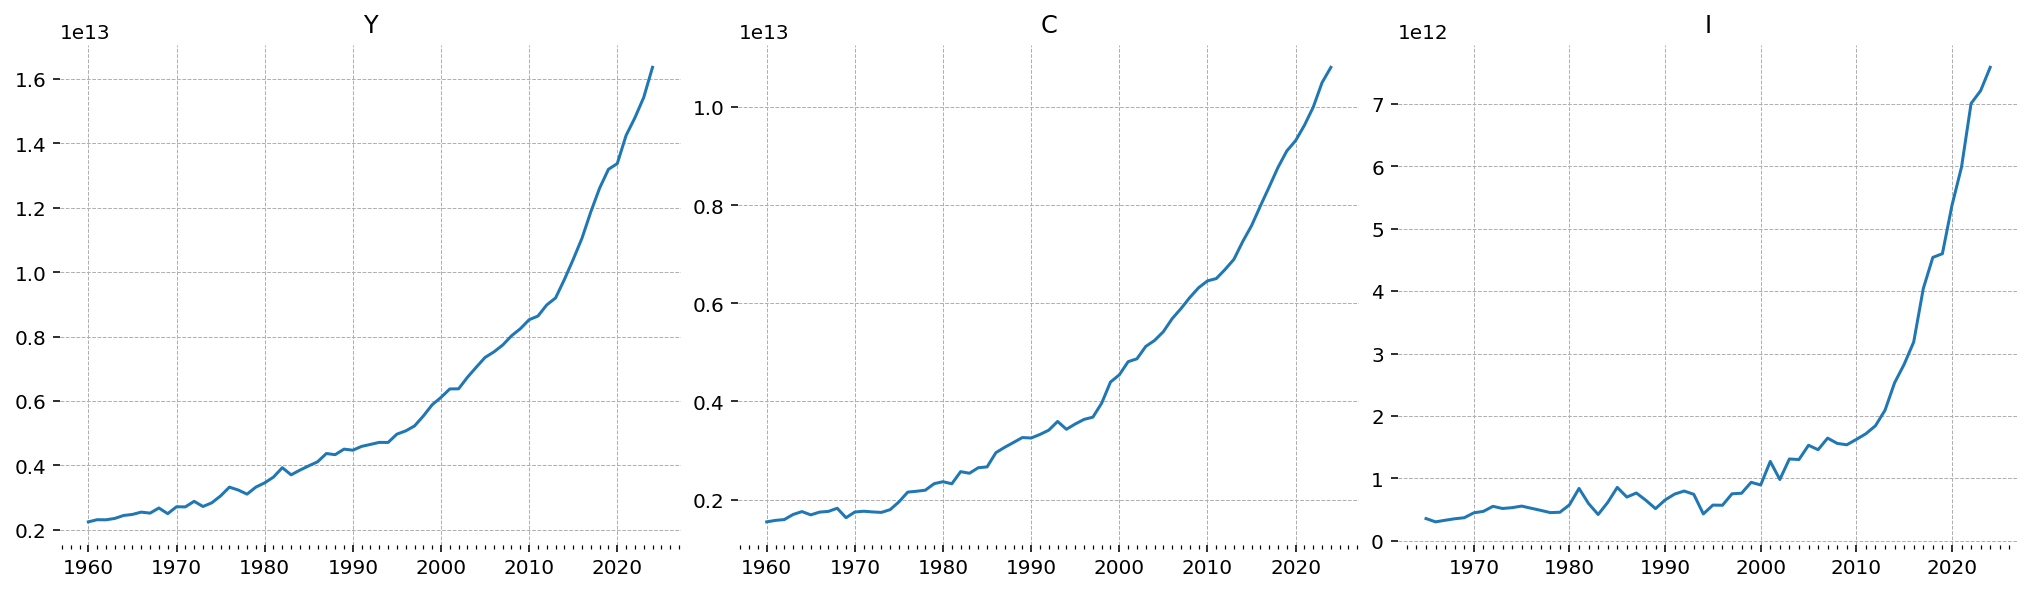

In [4]:
gp.plot_timeseries(df);

All three series are dominated by trend growth, spanning more than an order of magnitude over the sample, with consumption tracking output closely and investment more volatile. A stationary RBC speaks to the cyclical component rather than the trend, so the trend has to be removed first.

## Preprocessing

The RBC is solved by log-linearizing around its steady state, so each model variable is a percent deviation from steady state. To match this, we take logs of each series and keep the stationary cyclical component, discarding the slow-moving trend.

We use [`time_series_transformers`](https://github.com/jessegrabowski/time_series_transformers), a library of sklearn-style invertible transformers, chaining a `LogTransformer` with a `HamiltonFilterTransformer` inside an `InvertiblePipeline`. The [Hamilton (2018) filter](https://doi.org/10.1162/rest_a_00706) regresses $y_{t+h}$ on a constant and $p$ lags of $y$; the fitted values are the trend and the residual is the cycle. Its defaults, $h=2$ and $p=1$, follow Hamilton's recommendation for annual data, a two-year-ahead regression on one lag. Because the filter uses $h$ leads and $p$ lags, the first few years are returned as `NaN`; together with the missing early investment figures, the Kalman filter treats all of these as missing observations.

We use the Hamilton filter rather than the HP filter, which Hamilton argues can introduce spurious cyclical dynamics. One limitation is that the Hamilton trend is defined only on the estimation sample, so, unlike a fitted polynomial trend, it cannot be extrapolated to re-trend out-of-sample forecasts back to levels.

In [5]:
preprocess = InvertiblePipeline(
    [
        ("log", LogTransformer()),
        ("hamilton", HamiltonFilterTransformer()),
    ]
)
df_detrended = preprocess.fit_transform(df)
df_detrended.tail()

,Y,C,I
Time,,,
2020-01-01,-0.033306,-0.019595,0.014944
2021-01-01,-0.016471,-0.024871,0.110304
2022-01-01,0.007551,-0.010507,0.107608
2023-01-01,-0.016181,0.004544,0.024588
2024-01-01,0.003663,-0.004697,-0.086461


With the trend removed, the cyclical component remains: fluctuations of a few percent around zero, with output and consumption comoving and investment the most volatile. The first years are blank, since the Hamilton filter's lead and lag window and the missing early investment figures appear as the `NaN`s the Kalman filter skips.

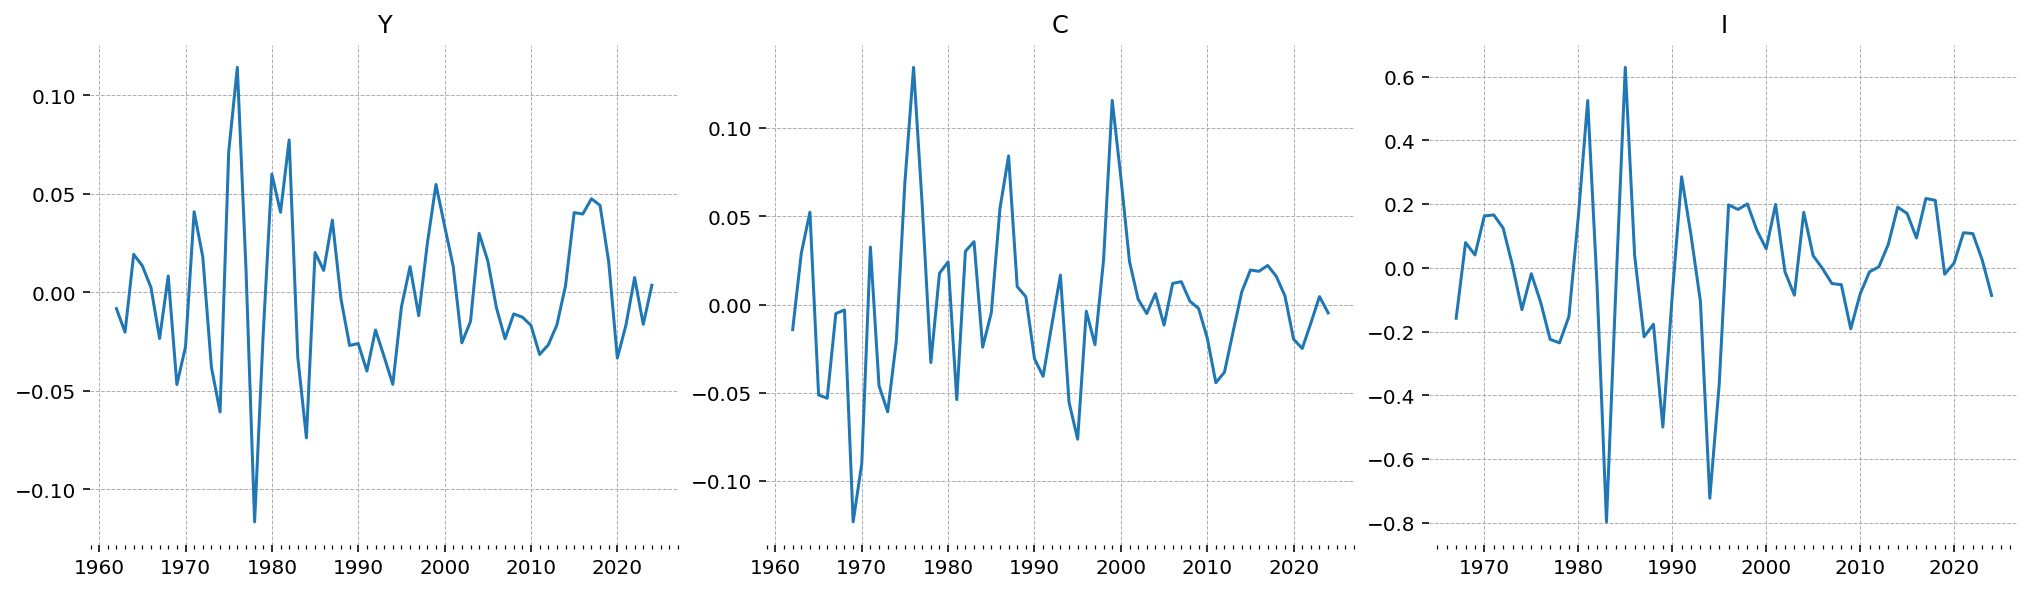

In [6]:
gp.plot_timeseries(df_detrended);

# Estimation with PyMC

With the data prepared, we build the model. As in the other estimation notebooks, the model is defined in a GCN file, whose contents `ge.print_gcn_file` prints. This is the standard quarterly RBC distributed with `gEconpy`. Its calibration is quarterly ($\beta = 0.99$, $\delta = 0.02$), which is why the latent states are quarterly even though the observations are annual.

In [7]:
file_path = ge.data.get_example_gcn("RBC")
ge.print_gcn_file(file_path)

## Building the state-space model

`ge.statespace_from_gcn` linearizes the model and wraps it in a `DSGEStateSpace` object for estimation. The build report lists the model's variables and shocks and indicates which parameters already have priors and which remain to be specified.

In [8]:
ss_mod = ge.statespace_from_gcn(file_path, missing_fill_value=-9999.0)

Model Building Complete.
Found:
	9 equations
	9 variables
		The following variables were eliminated at user request:
			TC_t, U_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	1 stochastic shock
		 0 / 1 have a defined prior.
	6 parameters
		 6 / 6 have a defined prior.
	0 parameters to calibrate.
	9 / 9 variables have analytical steady-state values.
		9 user-provided: A_ss, C_ss, I_ss, K_ss, L_ss, Y_ss, lambda_ss, 
                                 r_ss, w_ss
Model appears well defined and ready to proceed to solving.

Statespace model construction complete, but call the .configure method to finalize.


## Prior selection

Six deep parameters already have priors defined in the GCN file, `maxent` distributions chosen to place 99% of their mass in economically reasonable ranges. We inspect them with `gp.plot_priors`.

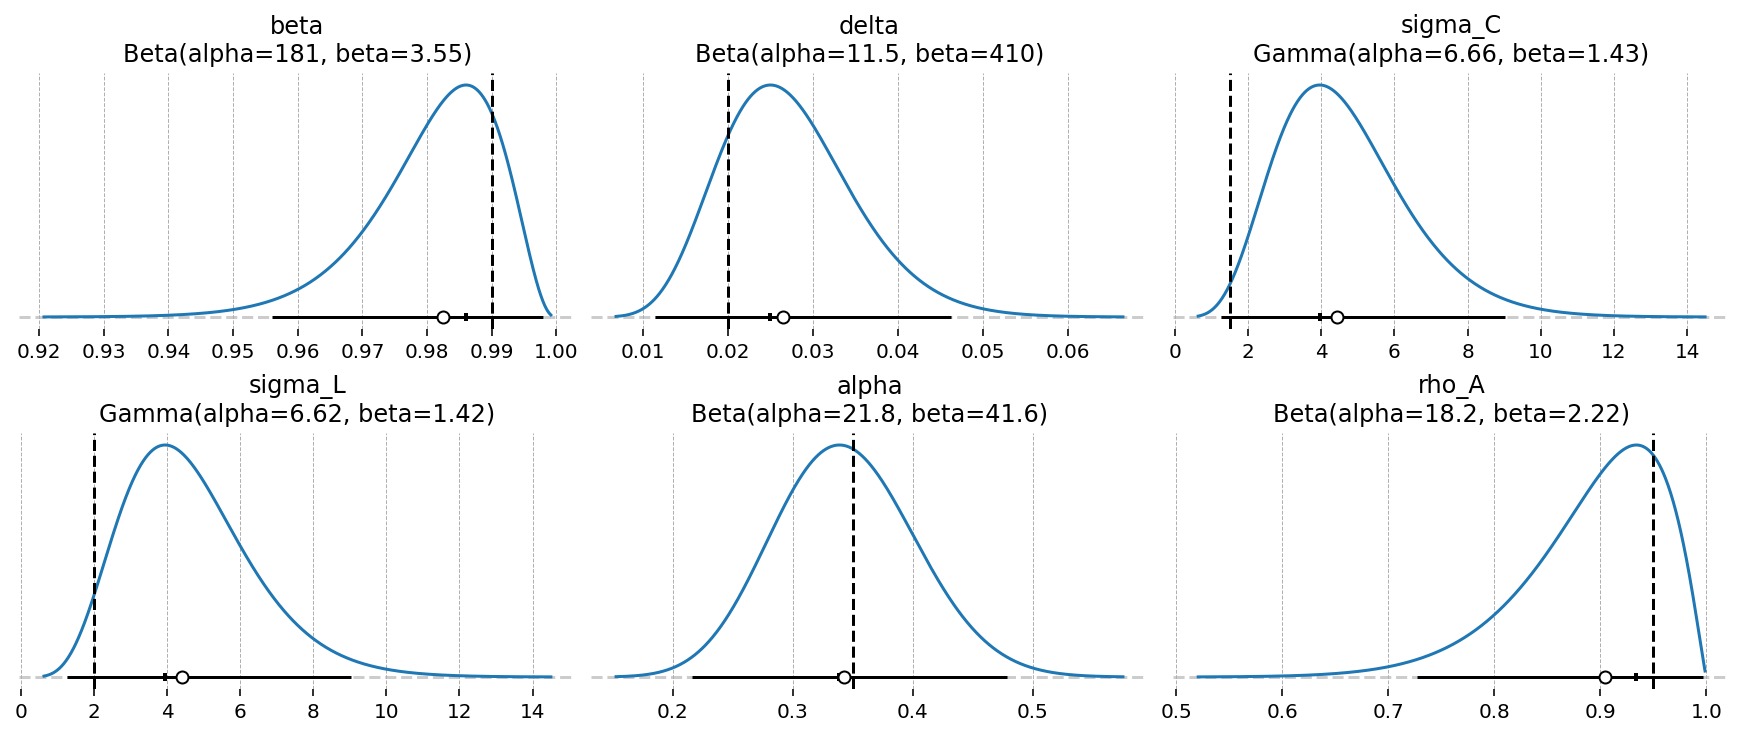

In [9]:
gp.plot_priors(ss_mod, n_cols=3, figsize=(12, 5));

## Configuring for mixed frequency

`.configure` finalizes the model for estimation. Three choices matter here.

- `observed_states`: the observed series are output, consumption, and investment, `["Y", "C", "I"]`.
- `measurement_error`: the model has a single structural shock (`epsilon_A`) but three observables. A linear state-space model can support at most as many noise-free observables as it has shocks, so we add measurement error to all three series to avoid stochastic singularity. The Kalman filter then determines, series by series, how much to trust the data relative to the model.
- `temporal_aggregation` and `aggregation_period`: these make the estimation mixed-frequency, specifying that each annual observation is formed from `aggregation_period=4` latent quarters.

### Why `"mean"` and not `"sum"`?

`gEconpy` offers `"sum"`, `"mean"`, `"first"`, and `"last"` aggregators. Output, consumption, and investment are flows, so annual GDP in levels is the sum of the four quarterly levels, which would suggest `"sum"`. The data here are log-deviations from trend rather than levels. Writing $\hat{y}_q$ for a quarter's log-deviation of output,

$$
\text{annual log-deviation} \;=\; \log\!\Big(\tfrac{1}{4}\textstyle\sum_{q} e^{\hat{y}_q}\Big) \;\approx\; \frac{1}{4}\sum_{q}\hat{y}_q
$$

to first order, so the annual log-deviation is the average of the four quarterly log-deviations rather than their sum. Using `"sum"` would scale the modeled observation up by a factor of four and bias the inferred shock size. (For an annual growth rate, log-differences do add over the year, and `"sum"` would be appropriate.)

Internally, `"mean"` augments the state vector with a cumulator block that carries a running average across each four-quarter window.

In [10]:
ss_mod.configure(
    observed_states=["Y", "C", "I"],
    measurement_error=["Y", "C", "I"],
    temporal_aggregation={"Y": "mean", "C": "mean", "I": "mean"},
    aggregation_period=4,
    mode="NUMBA",
    solver="gensys",
    use_adjoint_gradients=True,
    max_iter=20,
)

                  Model Requirements                  
                                                      
  Variable          Shape   Constraints   Dimensions  
 ──────────────────────────────────────────────────── 
  alpha             ()                          None  
  beta              ()                          None  
  delta             ()                          None  
  rho_A             ()                          None  
  sigma_C           ()                          None  
  sigma_L           ()                          None  
  sigma_epsilon_A   ()      Positive            None  
  error_sigma_Y     ()      Positive            None  
  error_sigma_C     ()      Positive            None  
  error_sigma_I     ()      Positive            None  
                                                      
 These parameters should be assigned priors inside a  
         PyMC model block before calling the          
            build_statespace_graph method.            

In [11]:
# Variable groups for plotting
deep_parameters = list(ss_mod.param_dict.keys())
shock_sigmas = [f"sigma_{name}" for name in ss_mod.shock_names]
noise_sigmas = [f"error_sigma_{name}" for name in ss_mod.error_states]

## Shaping the data

The Kalman filter runs on the quarterly grid, so we expand the annual series onto a quarterly index, leaving the three unobserved quarters of each year as `NaN`. `ge.prepare_mixed_frequency_data` does this; `observation_position="last"` places each annual value in the fourth quarter, where the four-quarter cumulator window completes. The filter treats every `NaN`, including the empty quarters, the Hamilton-filter warmup, and the missing early investment figures, as a missing observation and skips the update step.

In [12]:
mf_data = ge.prepare_mixed_frequency_data(
    df_detrended, high_freq="QS", aggregation_period=4, observation_position="last"
)
mf_data.tail(8)

,Y,C,I
2023-01-01,NaN,NaN,NaN
2023-04-01,NaN,NaN,NaN
2023-07-01,NaN,NaN,NaN
2023-10-01,-0.016181,0.004544,0.024588
2024-01-01,NaN,NaN,NaN
2024-04-01,NaN,NaN,NaN
2024-07-01,NaN,NaN,NaN
2024-10-01,0.003663,-0.004697,-0.086461


## Building the PyMC model

The build report's Model Requirements table lists the parameters that still need a prior. `ss_mod.to_pymc()` adds the six deep-parameter priors from the GCN. We then specify the remaining standard deviations: the shock size `sigma_epsilon_A` and one measurement-error scale per observed series.

Because the data are log-deviations, the measurement errors share those units (0.05 corresponds to about 5% off trend). For these we use `InverseGamma` priors rather than `Gamma`. An InverseGamma's density vanishes at zero, which rules out the case of perfectly measured data. This helps for two reasons. Near-zero measurement error is not plausible for developing-country national accounts, particularly gross capital formation, which is heavily revised and partly informal. A measurement-error scale that can approach zero also creates a degenerate posterior mode, since the filter can fit a single series exactly by trusting it completely; this manifests as a bimodal posterior for the investment error, with one mode near zero and another near 0.20, and destabilizes the sampler. The InverseGamma places its mass roughly in the 2–20% range and removes that mode.

`pz.maxent` returns the maximum-entropy distribution in a family with a chosen share of its mass between two points, which is easier to reason about than the raw distribution parameters.

In [13]:
with pm.Model(coords=ss_mod.coords) as senegal_rbc:
    ss_mod.to_pymc()

    prior_dict = ss_mod.param_priors.copy()

    # TFP innovation size
    prior_dict["sigma_epsilon_A"] = pz.maxent(pz.Gamma(), lower=0.01, upper=0.1)
    prior_dict["sigma_epsilon_A"].to_pymc("sigma_epsilon_A")

    # InverseGamma density vanishes at 0, ruling out zero measurement error
    for name in ss_mod.error_states:
        d = pz.maxent(pz.InverseGamma(), lower=0.02, upper=0.2)
        prior_dict[f"error_sigma_{name}"] = d
        d.to_pymc(f"error_sigma_{name}")

    ss_mod.build_statespace_graph(
        data=mf_data[list(ss_mod.observed_states)],
        add_norm_check=False,
        add_solver_success_check=True,
    )

/Users/jessegrabowski/mambaforge/envs/geconpy-dev/lib/python3.12/site-packages/pymc_extras/statespace/utils/data_tools.py:179: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)


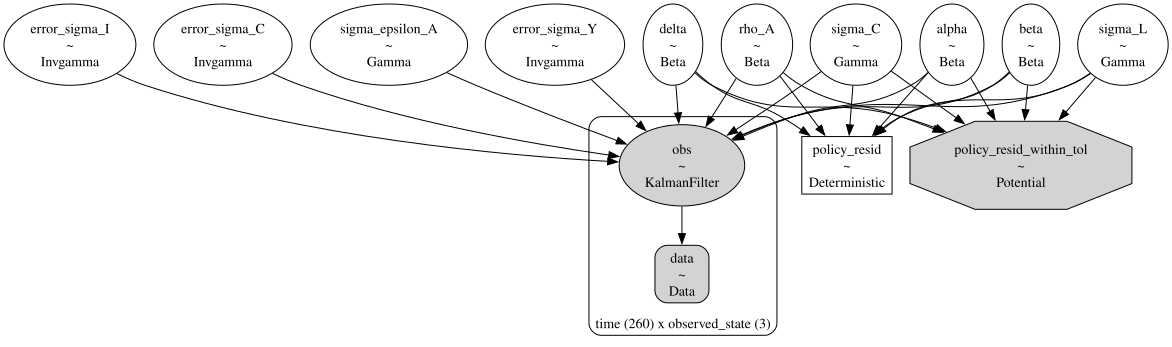

In [14]:
senegal_rbc.to_graphviz()

## Sampling

We sample with NUTS via [`nutpie`](https://github.com/pymc-devs/nutpie), compiling the model through the JAX backend. DSGE posteriors often have difficult geometry, so we use nutpie's normalizing-flow adaptation (`transform_adapt`) to help the sampler adapt to it. This is the most expensive cell in the notebook and may take some time to run.

In [15]:
with senegal_rbc:
    idata = pm.sample(initvals=ss_mod.param_dict, random_seed=RANDOM_SEED)

NUTS[nutpie]: [beta, delta, sigma_C, sigma_L, alpha, rho_A, sigma_epsilon_A, error_sigma_Y, error_sigma_C, error_sigma_I]


Output()

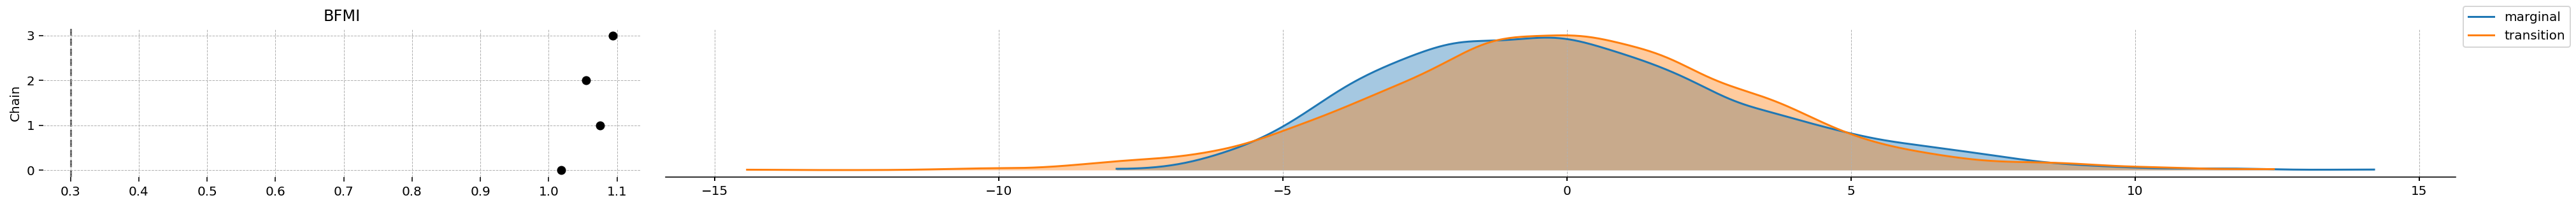

In [16]:
az.plot_energy(idata)

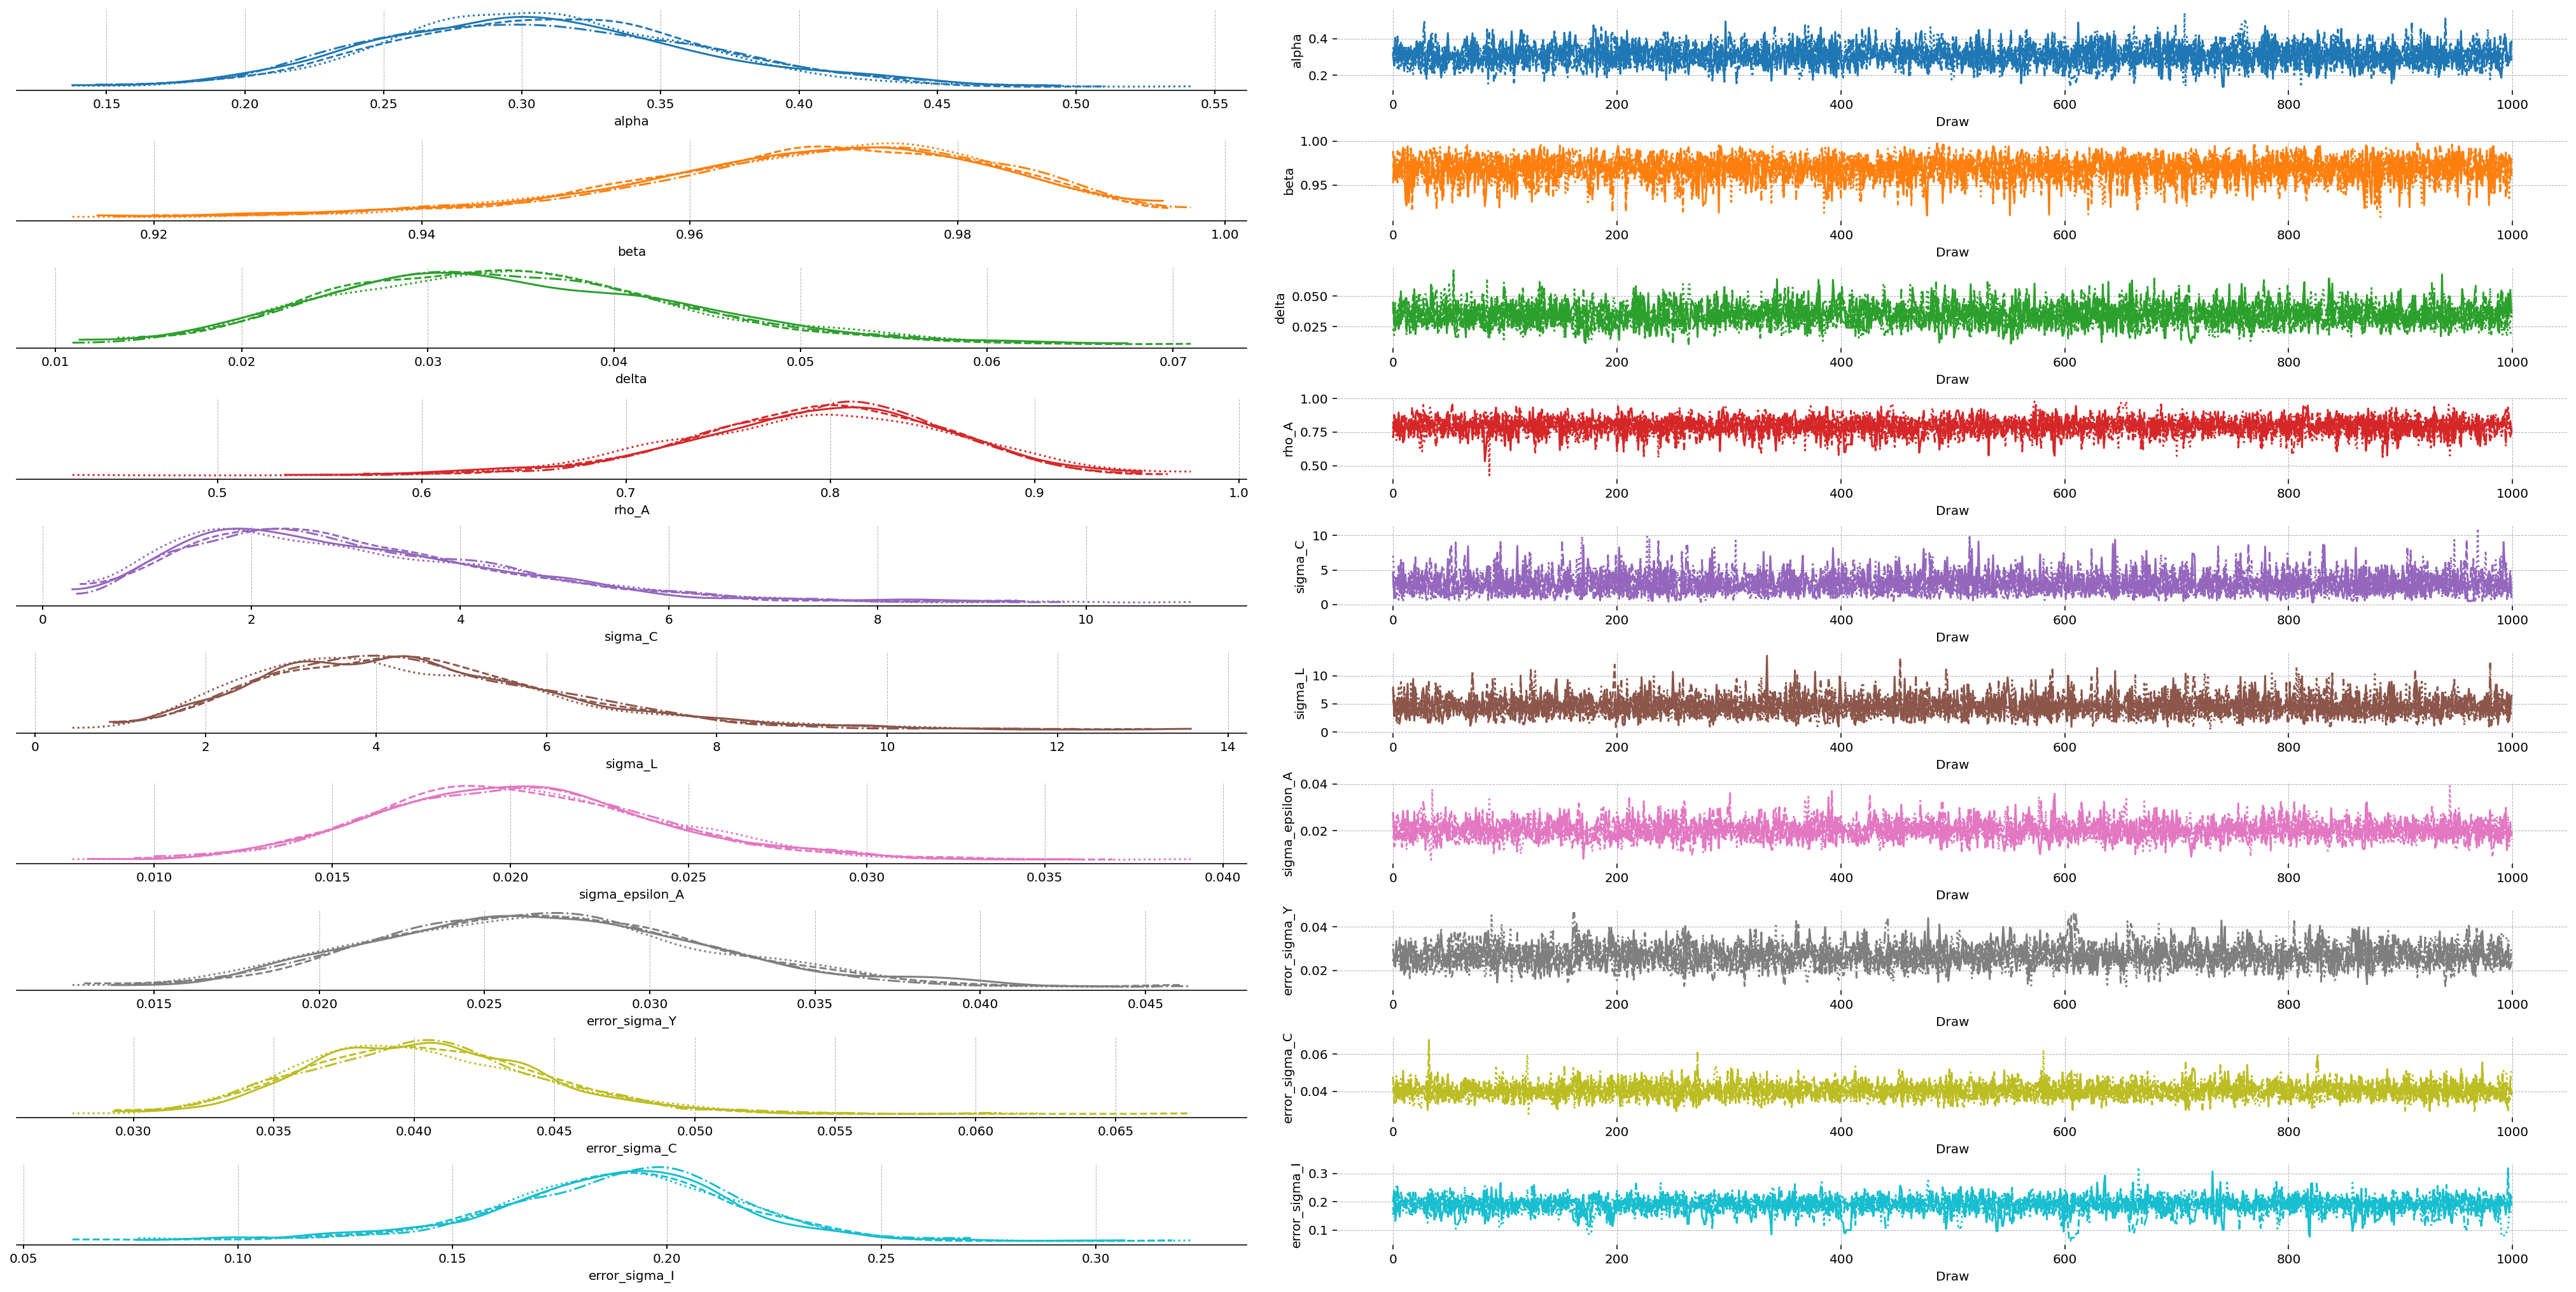

In [17]:
az.plot_trace_dist(idata, var_names=list(ss_mod.param_names))

### Sampler diagnostics

The diagnostics are reassuring: no divergences, $\hat{R} = 1.00$ for every parameter, and bulk effective sample sizes between roughly 2,000 and 5,000 across the four chains. In the energy plot the marginal and transition-energy distributions overlap closely, which indicates that NUTS is exploring the tails of the posterior adequately, and the marginal traces are smooth and unimodal, with no chain separating from the others.

## Posterior vs. prior

A first check is how far the data move each structural parameter from its prior; `gp.plot_posterior_with_prior` overlays the two for the deep parameters.

The deep-parameter posteriors are only slightly narrower than their priors, consistent with annual data carrying limited information about structural parameters, a point the frequency discussion below develops. The data tend to shift these parameters rather than sharpen them, and the size of the shift varies: $\rho_A$ and $\beta$ move most, $\sigma_L$ very little. The next cell quantifies this comparison. The clearer reduction in uncertainty is concentrated in the shock and measurement-error scales, whose posteriors are considerably tighter than their priors.

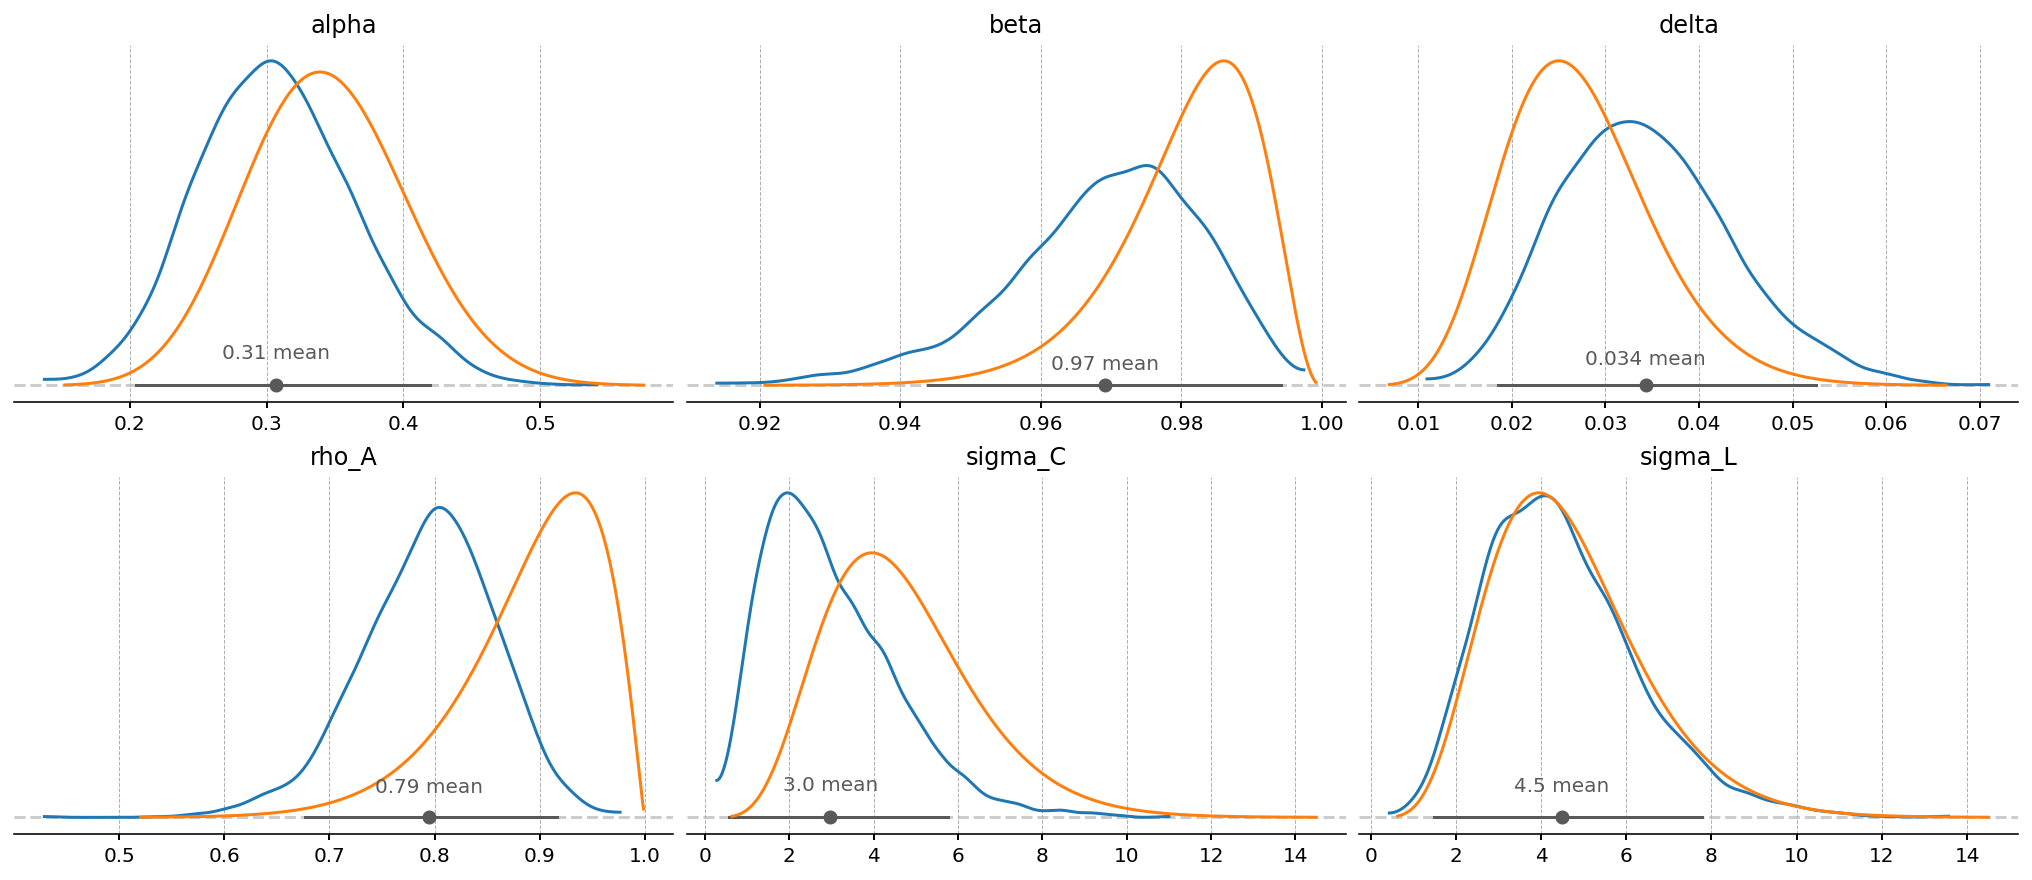

In [18]:
gp.plot_posterior_with_prior(idata, var_names=deep_parameters, prior_dict=prior_dict, n_cols=3);

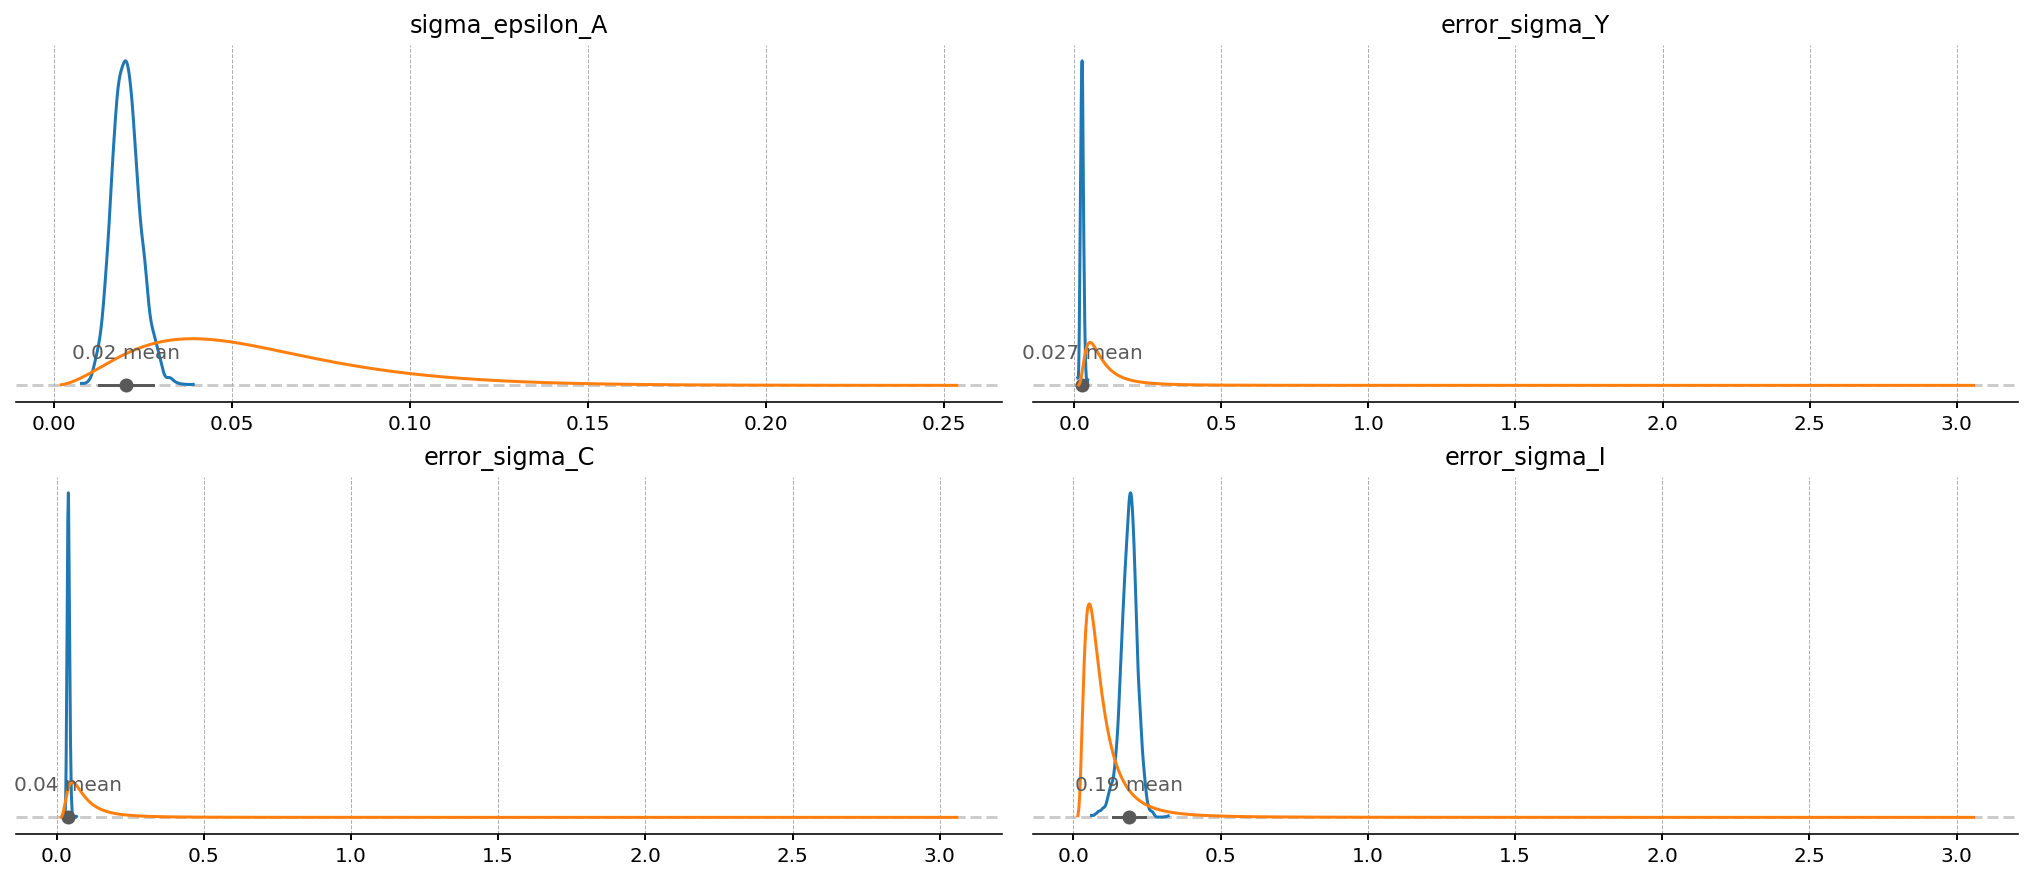

In [19]:
gp.plot_posterior_with_prior(idata, var_names=shock_sigmas + noise_sigmas, prior_dict=prior_dict, n_cols=2);

### Quantifying the update

The overlay is qualitative; a summary statistic makes it quantitative. One option is the Wasserstein-1 (earth-mover) distance between each parameter's prior and posterior, the minimal cost of transporting one distribution onto the other. To compare parameters measured on very different scales, we standardize both prior and posterior by the prior mean and standard deviation before computing the distance, so it is expressed in prior-standard-deviation units. A parameter the data leave unchanged scores near zero, while one the data move or sharpen by about a prior standard deviation scores near one. `arviz_stats.wasserstein` performs the computation; we draw a prior sample from each `preliz` distribution to compare against the posterior draws.

/Users/jessegrabowski/mambaforge/envs/geconpy-dev/lib/python3.12/site-packages/pytensor/tensor/random/basic.py:476: FutureWarning: Gamma rate argument is deprecated and will stop working, use scale instead
  warnings.warn(


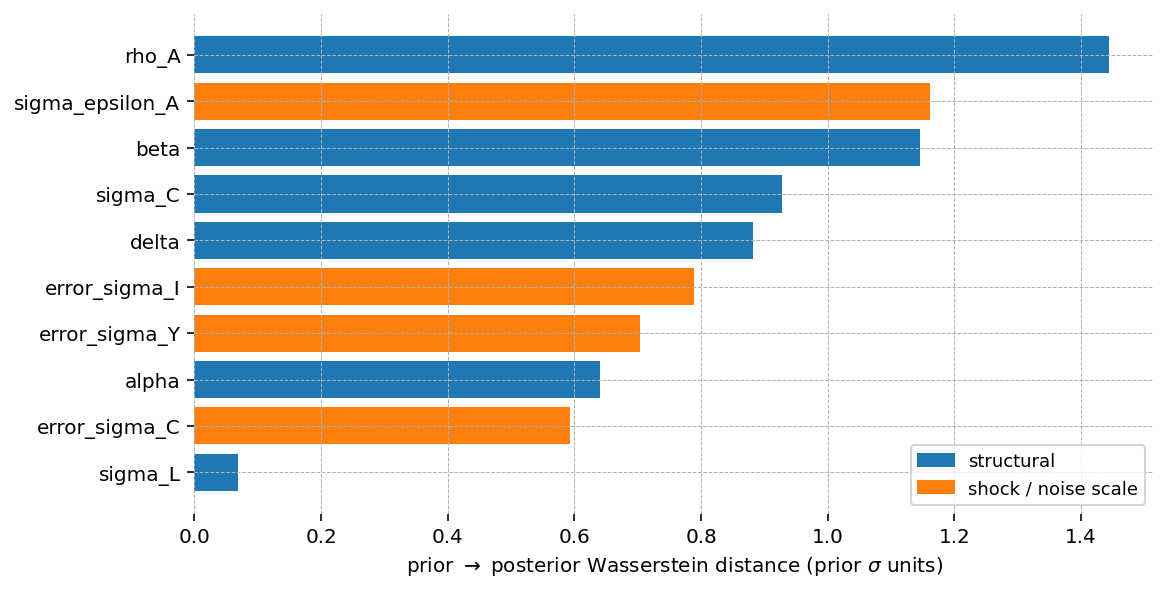

In [20]:
params = deep_parameters + shock_sigmas + noise_sigmas
n_samples = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
sample_coord = {"sample": np.arange(n_samples)}

updating = {}
for name in params:
    prior = prior_dict[name]
    mu, sd = float(prior.mean()), float(prior.std())
    prior_z = (np.asarray(prior.rvs(n_samples)) - mu) / sd
    post_z = (idata.posterior[name].values.ravel() - mu) / sd
    prior_ds = xr.Dataset({name: ("sample", prior_z)}, coords=sample_coord)
    post_ds = xr.Dataset({name: ("sample", post_z)}, coords=sample_coord)
    updating[name] = float(
        azs.wasserstein(prior_ds, post_ds, sample_dims=["sample"], joint=False, num_samples=n_samples, round_to="none")
    )

updating = pd.Series(updating).sort_values()
is_scale = updating.index.isin(shock_sigmas + noise_sigmas)

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.barh(updating.index, updating.values, color=np.where(is_scale, "tab:orange", "tab:blue"))
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ("tab:blue", "tab:orange")],
    labels=["structural", "shock / noise scale"],
    fontsize=9,
)
ax.set(xlabel=r"prior $\rightarrow$ posterior Wasserstein distance (prior $\sigma$ units)")
ax.grid(axis="x", ls="--", lw=0.5)
plt.show()

Two features stand out. $\sigma_L$ moves least, under 0.1 prior standard deviations, so the data are close to uninformative about the Frisch elasticity, consistent with the overlay above. The remaining parameters update by roughly a prior standard deviation or more, with the technology block ($\rho_A$ and the shock size $\sigma_{\epsilon_A}$) the largest. For the structural parameters the distance mostly reflects relocation: because their posteriors change little in width, it measures how far the data shifted them rather than how much they tightened. The measurement-error scales update in the other sense, contracting from a diffuse prior onto a tight posterior. Since the distance is expressed in prior-standard-deviation units and does not separate these two effects, the sharply contracted scales rank below the most relocated structural parameters.

### Interpreting the parameters: frequency

A reasonable concern is whether annual data force the estimated $\beta$ to take an annual value (around 0.96) rather than a quarterly one. They do not. `prepare_mixed_frequency_data` places the series on a quarterly grid with `NaN` in three of every four quarters, so the filter predicts with the quarterly transition $T(\beta, \delta, \dots)$ each quarter and updates only in the fourth, when an observation arrives. Four quarterly steps separate consecutive observations, each governed by the quarterly $\beta$, so the likelihood identifies $\beta$ at its quarterly value. A point-sampling analogy is useful: sampling a quarterly AR(1) once a year yields an annual autocorrelation of $\rho^4$, but estimating a quarterly AR(1) that accounts for the three missing quarters recovers $\rho$ itself. Recovering the quarterly parameters in this way is the reason for keeping the model quarterly.

The estimates should therefore be read at the model's frequency. $\beta \approx 0.97$ is quarterly (annual $\beta^4 \approx 0.88$), $\delta \approx 0.03$ is quarterly depreciation (about 13% a year), and $\rho_A \approx 0.79$ is quarterly TFP persistence (annual $\approx 0.40$). The cost of annual data is precision rather than frequency: fewer observations, together with the four-quarter averaging, identify the structural parameters only weakly, which is why their posteriors remain close to the priors. The `"mean"` versus `"sum"` choice does not affect this, since it rescales the observation equation by a constant that the shock and measurement-error scales absorb, leaving the structural parameters unchanged.

## Joint posterior

A corner plot shows the marginal posteriors on the diagonal and the pairwise joint distributions off it, which help identify parameters the data cannot separately pin down (a diagonal ridge) or economic trade-offs between them. Here there is little of either: every pairwise posterior correlation is below 0.15 in magnitude, so the joint distributions are close to circular. With the data only weakly constraining the structural block, the parameters are nearly independent in the posterior, each determined largely by its own prior rather than by trade-offs against the others.

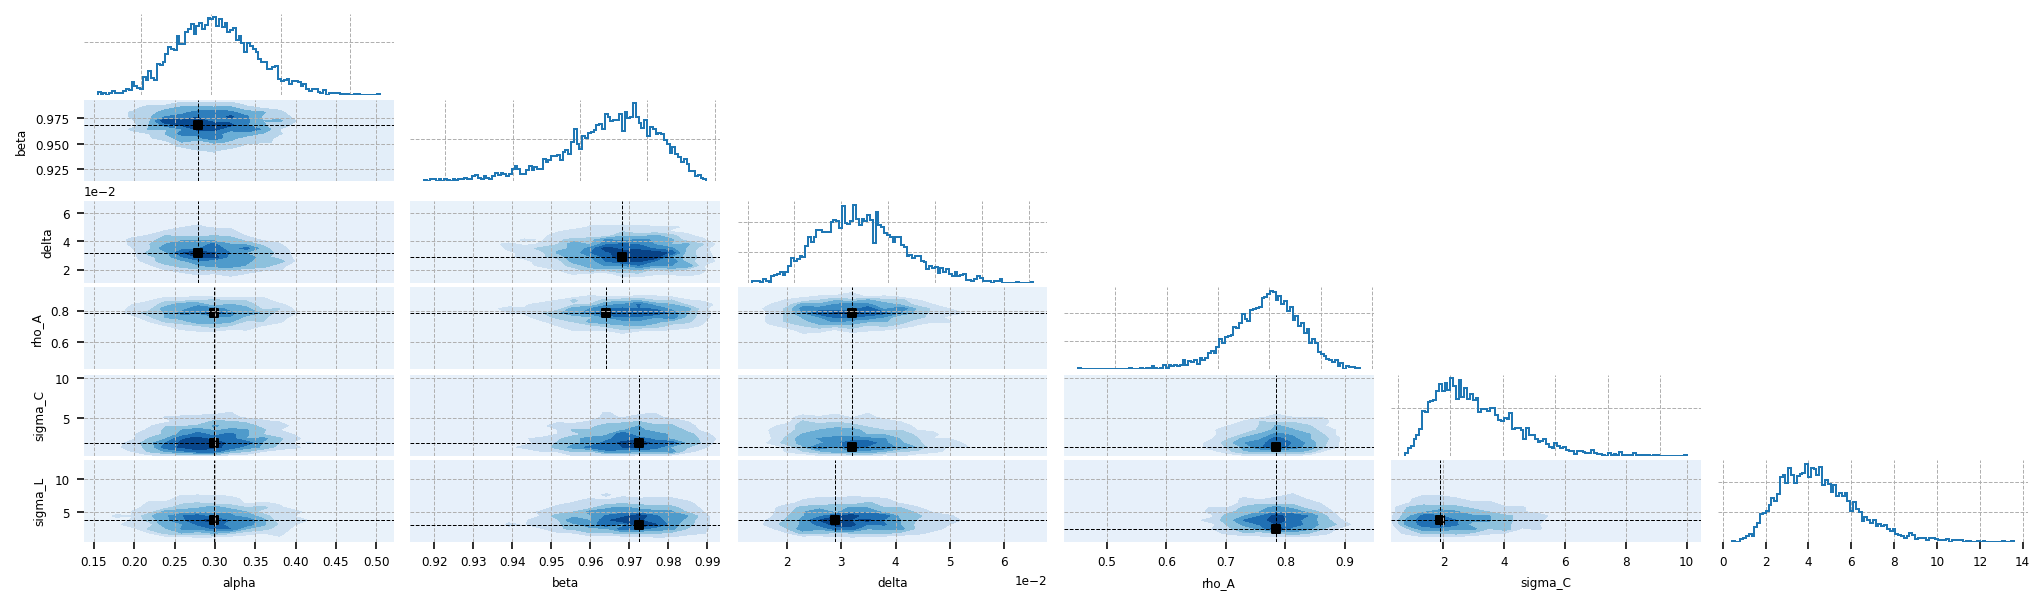

In [21]:
gp.plot_corner(idata, var_names=deep_parameters);

## Kalman-filter fit and forecast

`sample_conditional_posterior` runs the smoother to recover the latent quarterly path implied by the annual data. We plot it in the detrended (Hamilton-cycle) space against the sparse annual observations. The quarterly states interpolating between the observed points are the main object of interest in the mixed-frequency setup.

In [22]:
conditional = ss_mod.sample_conditional_posterior(idata, random_seed=rng)

/Users/jessegrabowski/mambaforge/envs/geconpy-dev/lib/python3.12/site-packages/pymc_extras/statespace/utils/data_tools.py:179: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

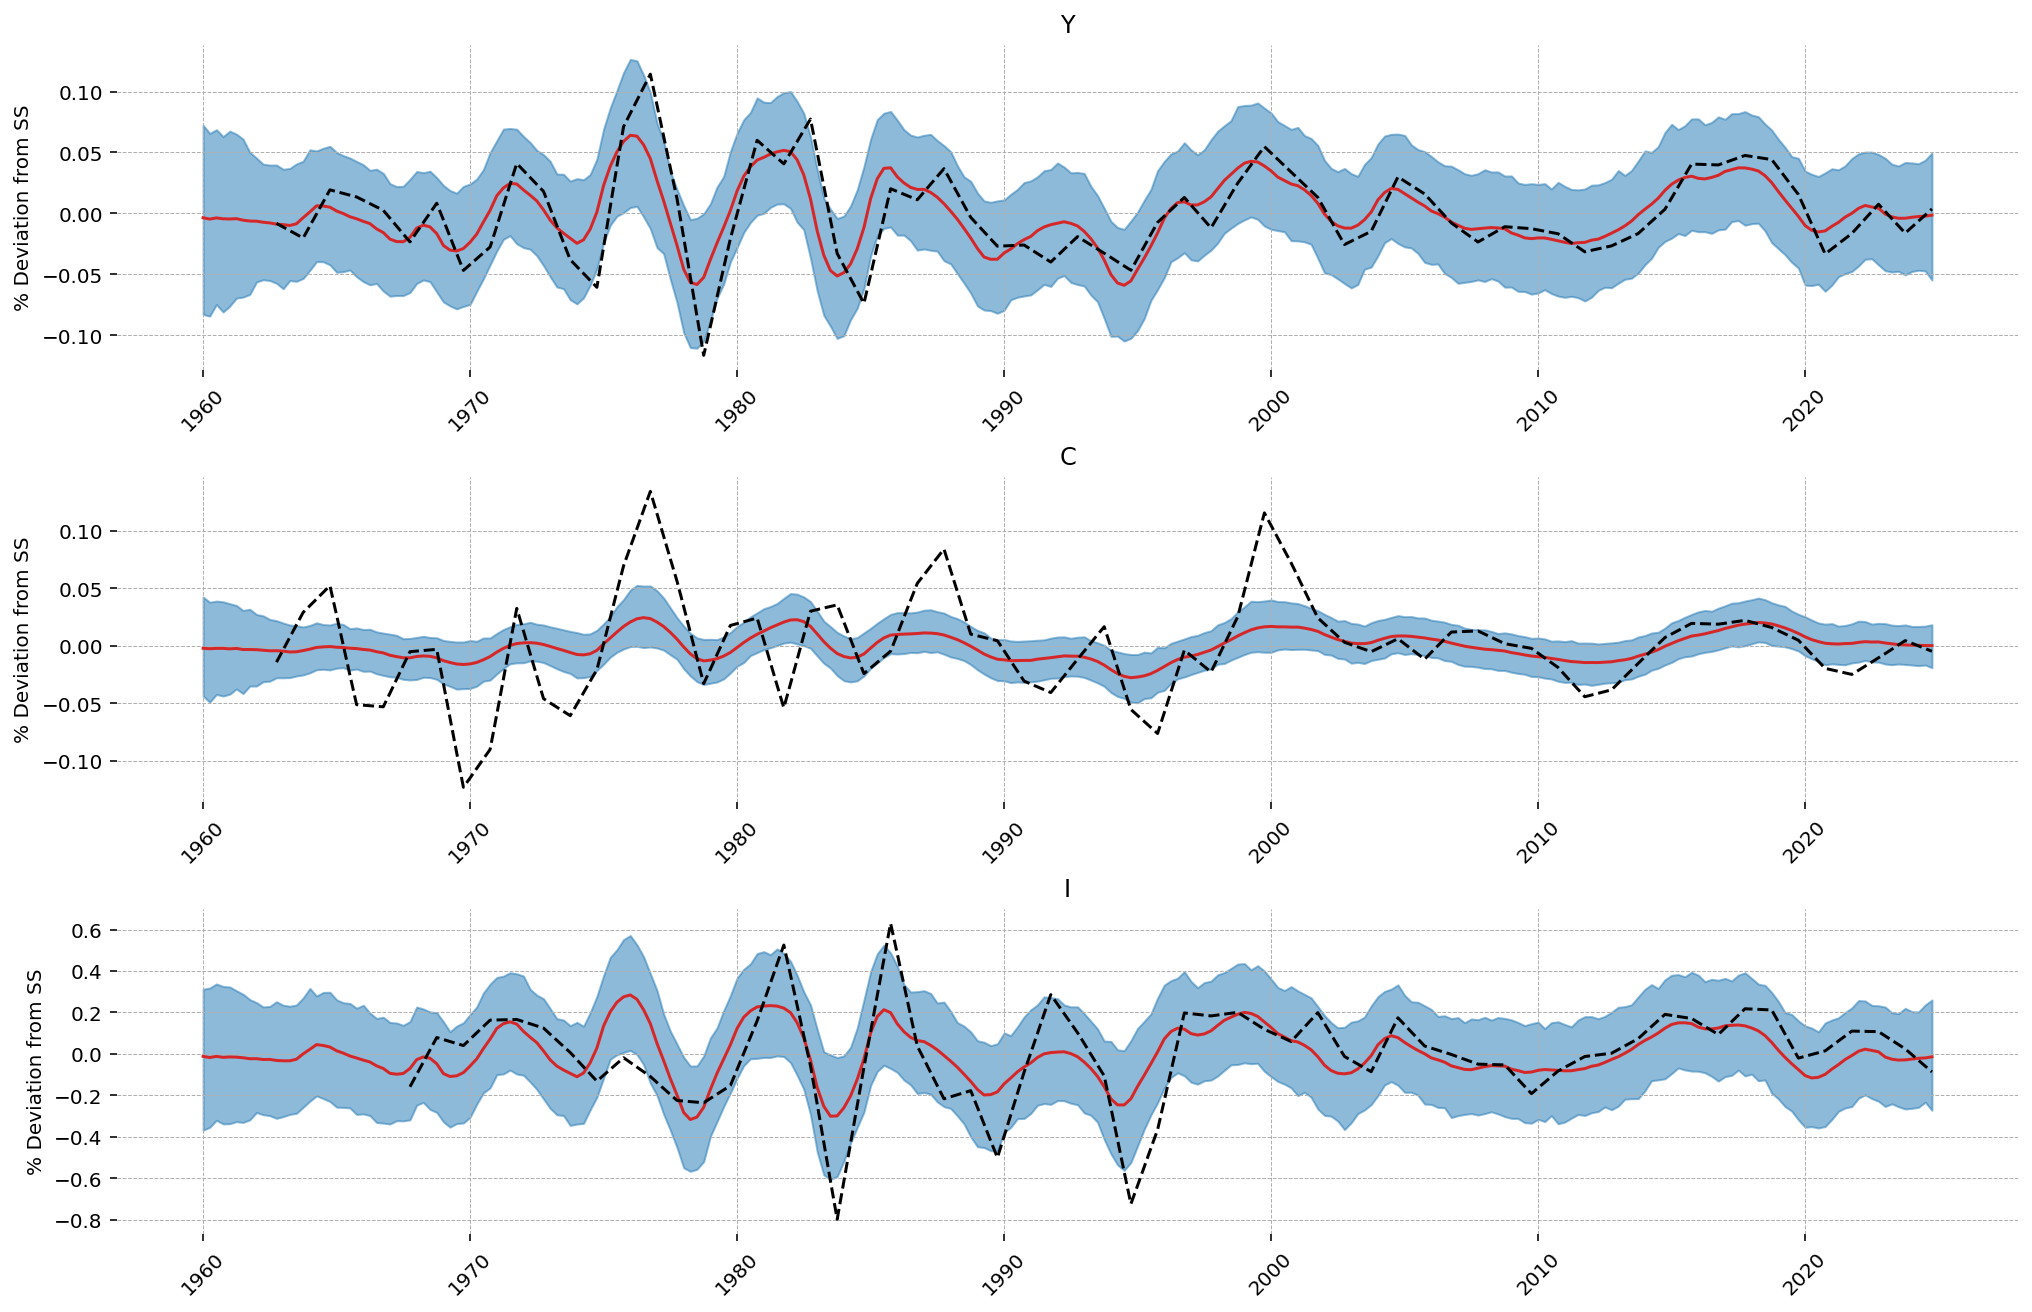

In [23]:
gp.plot_kalman_filter(
    conditional,
    data=mf_data.interpolate("linear"),
    kalman_output="smoothed",
    vars_to_plot=["Y", "C", "I"],
    n_cols=1,
    figsize=(14, 9),
);

The smoothed quarterly path passes through the annual observations and interpolates the three unobserved quarters of each year using the model's dynamics. The credible band is widest for investment, the series the filter trusts least, consistent with its large estimated measurement error.

### Unobserved states

The smoother also returns the variables that are not observed. Because the model links all variables, the same inferred path implies quarterly trajectories for total factor productivity $A_t$, the capital stock $K_t$, hours $L_t$, the real wage $w_t$, and the real interest rate $r_t$. None of these enter the likelihood; they are the model's implied values given the three annual series and its cross-equation structure. A quarterly interest-rate path, for example, is produced without any interest-rate data as input.

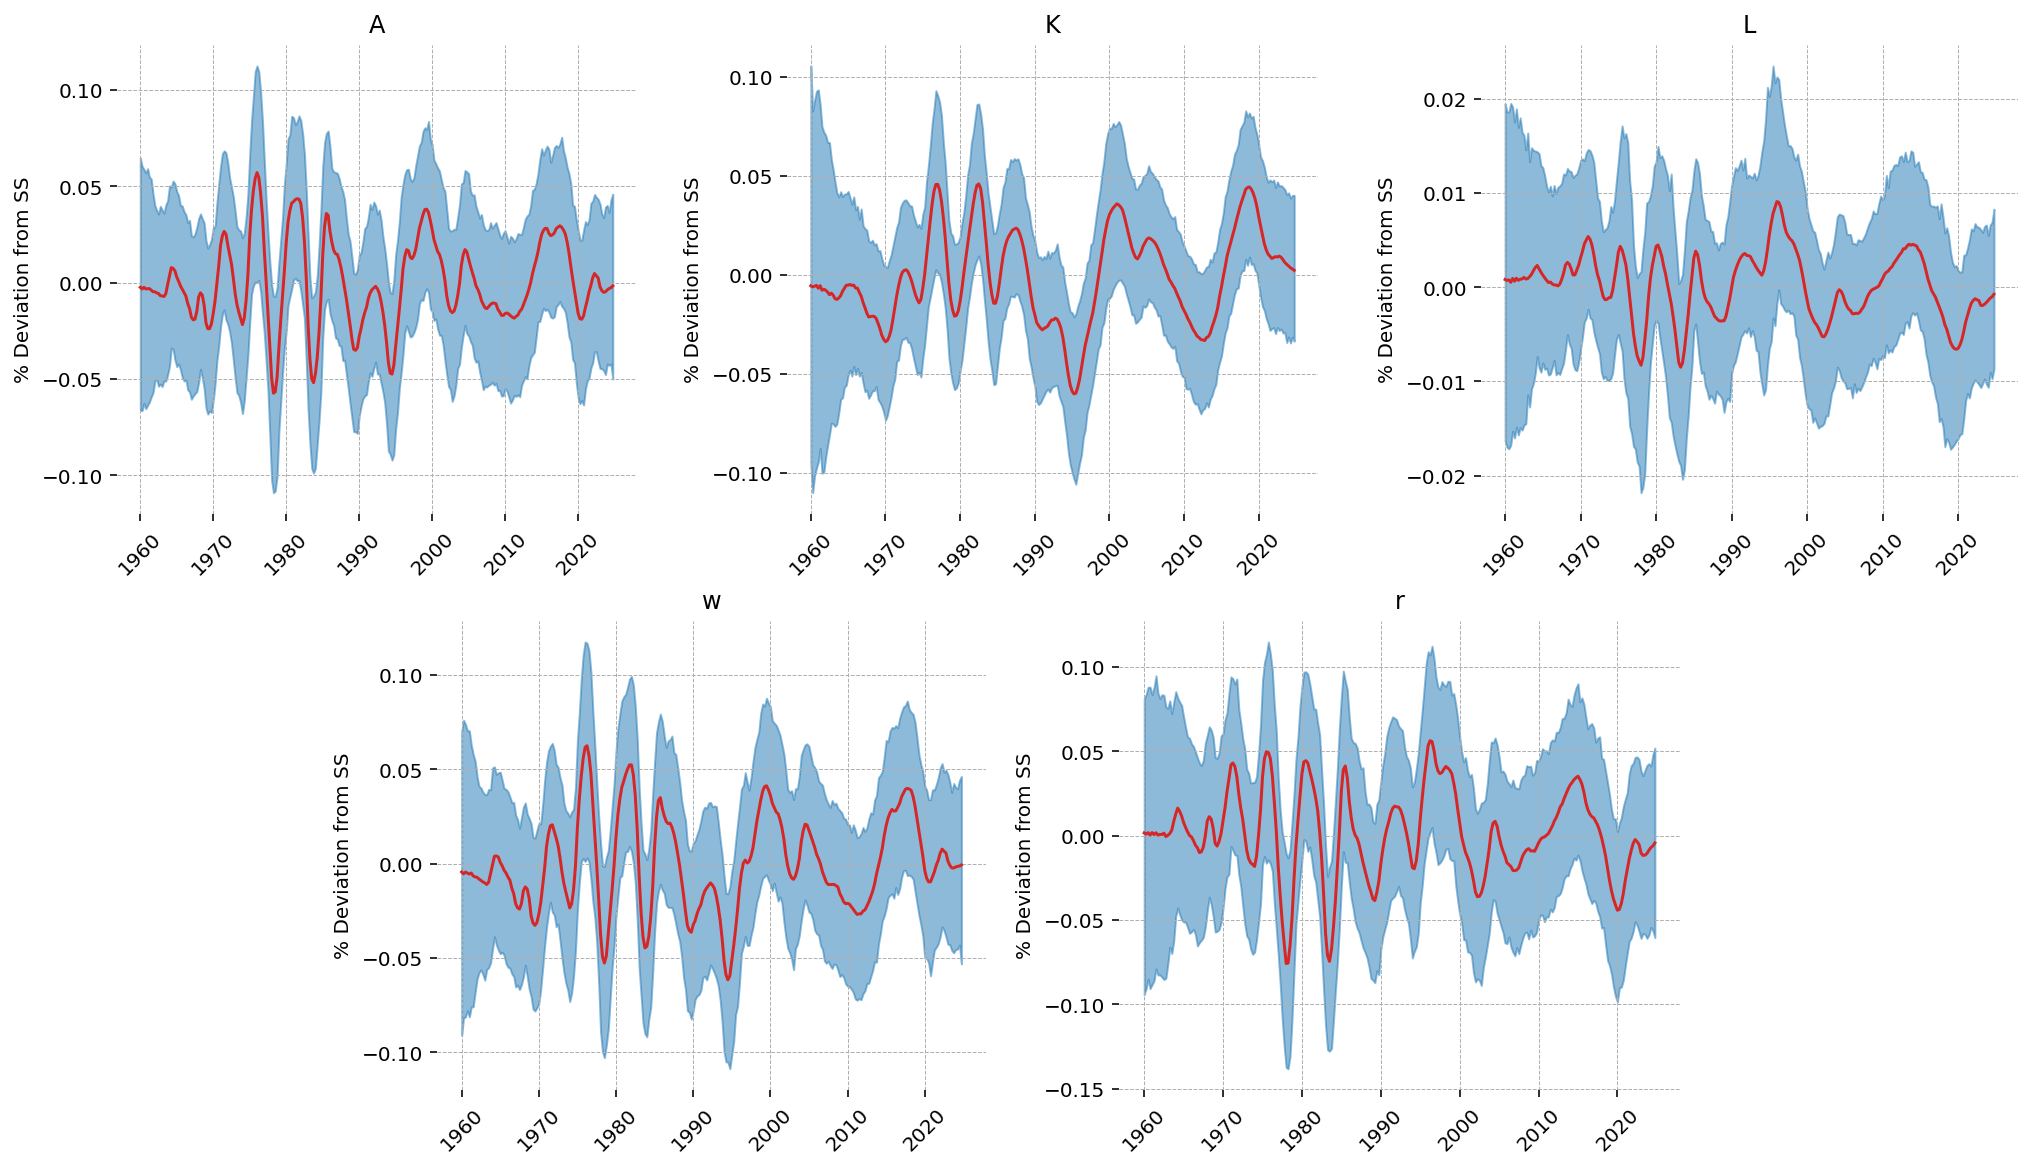

In [24]:
gp.plot_kalman_filter(
    conditional,
    data=mf_data,
    kalman_output="smoothed",
    vars_to_plot=["A", "K", "L", "w", "r"],
    n_cols=3,
    figsize=(14, 8),
);

## Observed and latent series

The previous plot is in the latent space: the smoothed quarterly states the model reconstructs, none of which are observed directly. Recovering this quarterly path is the aim of mixed-frequency estimation, but it is not the appropriate comparison to the data. The measured series are the observed ones, in which each year's value is the four-quarter average produced by the measurement equation (the `"mean"` aggregation introduced earlier).

`conditional` contains both: `smoothed_posterior` for the latent quarterly states and `smoothed_posterior_observed` for the model-implied observables. The in-sample fit is best assessed by comparing the observed smoother to the data, since the two share the same annual-aggregate footing. The next cell plots this alongside the out-of-sample `forecast`, also in observed space, and the data. In sample, the smoothed observable should pass through the annual points; out of sample, the forecast carries the implied annual path forward, reverting toward steady state as the estimated TFP shock decays, with the credible interval widening as future shocks accumulate.

In [25]:
forecast = ss_mod.forecast(idata, start=mf_data.index[-1], periods=20, random_seed=rng)

/Users/jessegrabowski/mambaforge/envs/geconpy-dev/lib/python3.12/site-packages/pymc_extras/statespace/utils/data_tools.py:179: ImputationWarning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.
  warnings.warn(impute_message, ImputationWarning)
Sampling: [forecast_combined]


Output()

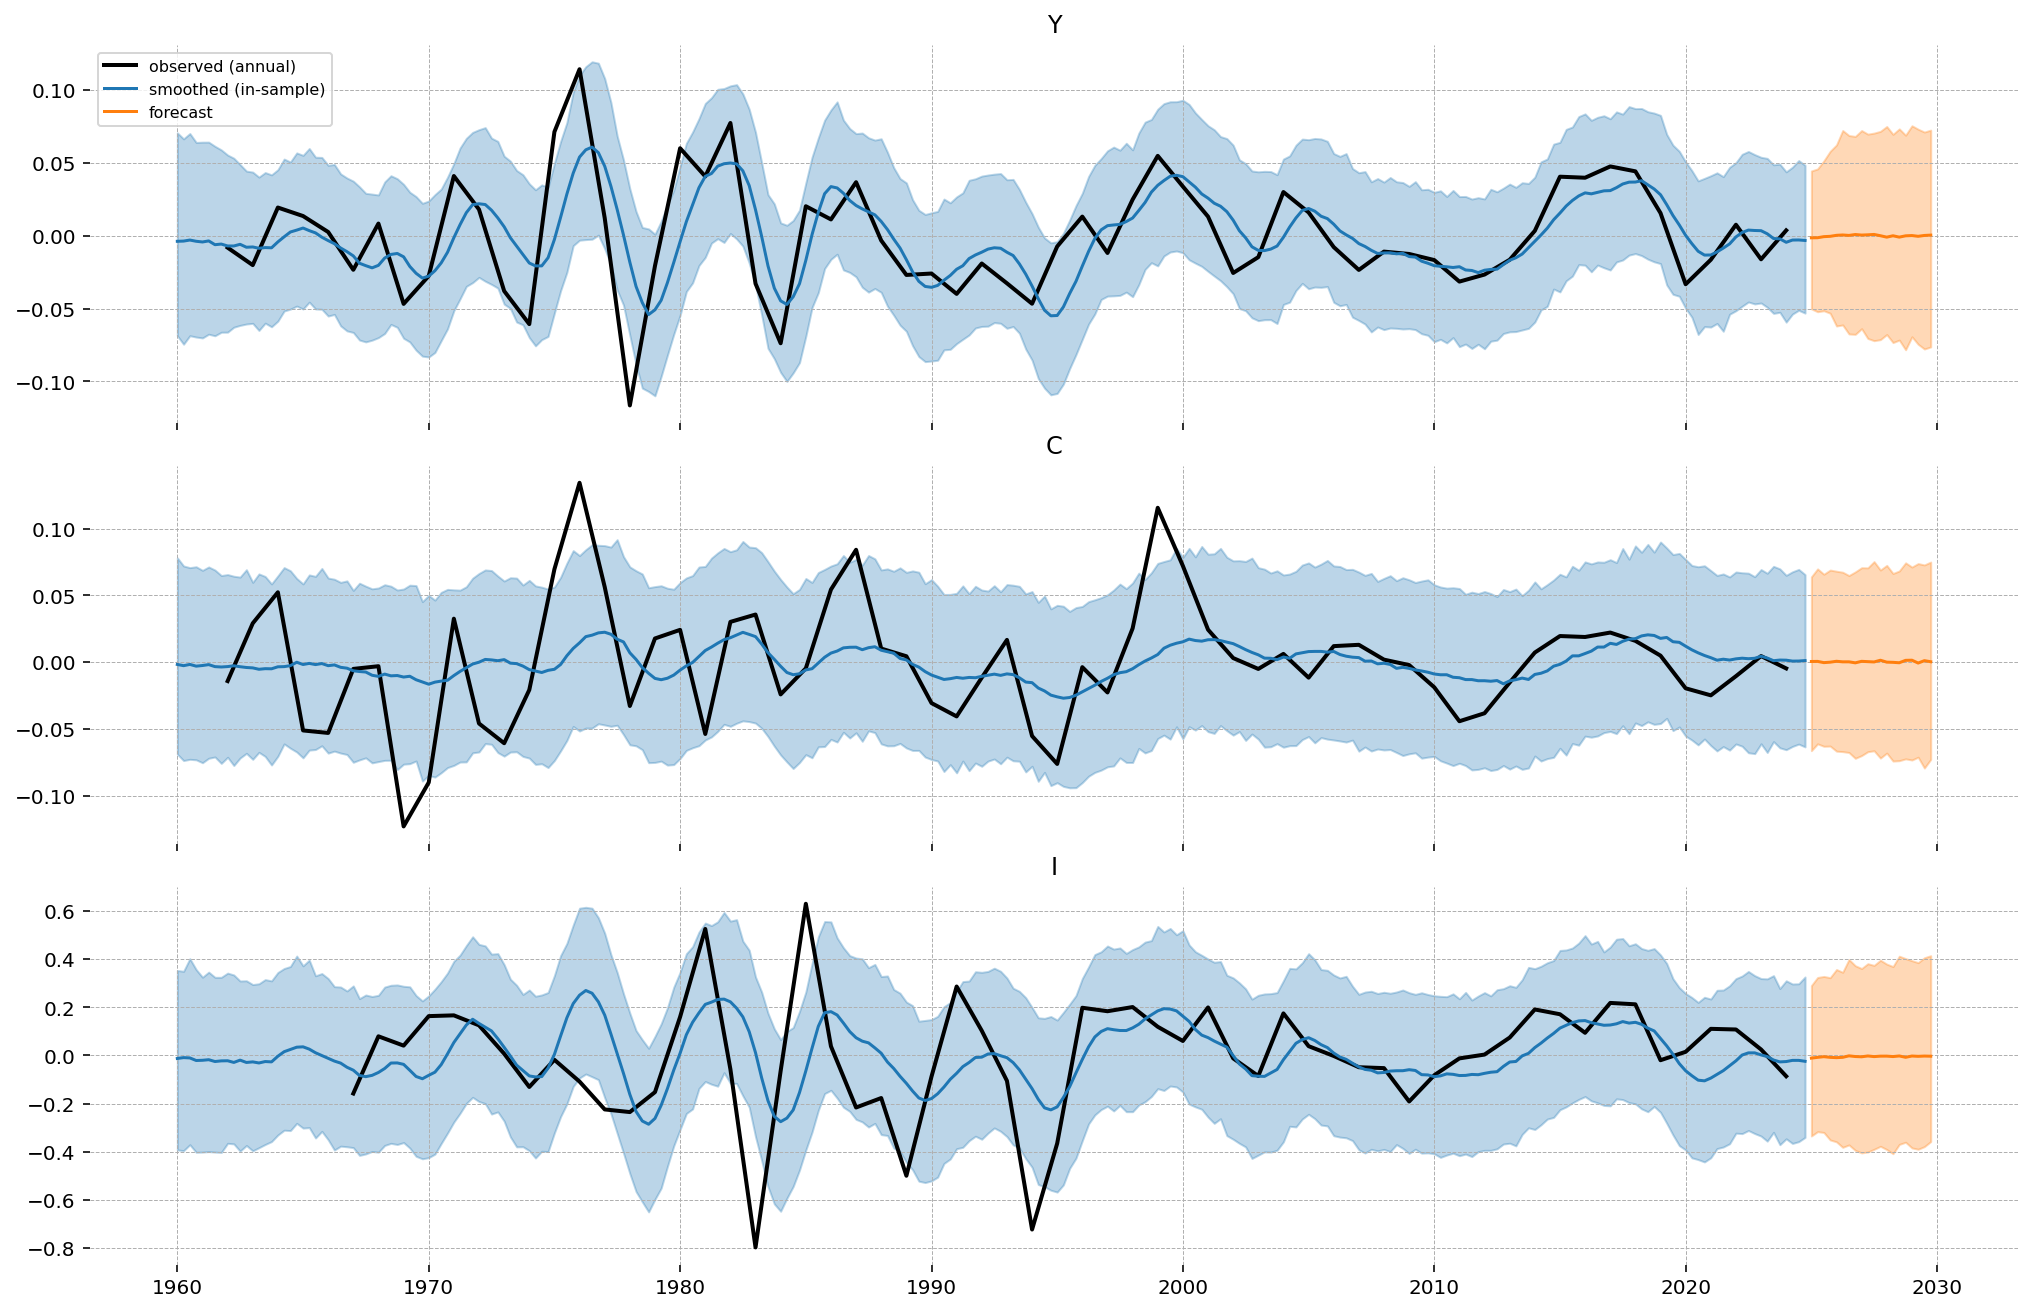

In [26]:
smoothed_obs = conditional.smoothed_posterior_observed
forecast_obs = forecast.dataset.forecast_observed

s_dates = smoothed_obs.coords["time"].values
f_dates = forecast.coords["time"].values
s_mu = smoothed_obs.mean(dim=["chain", "draw"])
f_mu = forecast_obs.mean(dim=["chain", "draw"])
s_hdi = az.hdi(smoothed_obs)
f_hdi = az.hdi(forecast_obs)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, layout="constrained")

for ax, var in zip(axes, ["Y", "C", "I"], strict=False):
    obs = df_detrended[var].dropna()
    ax.plot(obs.index, obs.values, c="k", lw=2, label="observed (annual)")

    ax.plot(s_dates, s_mu.sel(observed_state=var).values, color="C0", label="smoothed (in-sample)")
    ax.fill_between(s_dates, *s_hdi.sel(observed_state=var).values.T, color="C0", alpha=0.3)

    ax.plot(f_dates, f_mu.sel(observed_state=var).values, color="C1", label="forecast")
    ax.fill_between(f_dates, *f_hdi.sel(observed_state=var).values.T, color="C1", alpha=0.3)

    ax.set_title(var)
axes[0].legend(fontsize=8)
plt.show()

In sample, the model-implied annual observable (blue) tracks the data (black) closely for output and consumption and more loosely for the noisier investment series, with the four-quarter average reproducing the annual points used in estimation. Out of sample, the forecast reverts toward steady state as the estimated TFP shock decays, and the band widens as future shocks accumulate. The forecast is not re-trended: the Hamilton filter has no out-of-sample continuation, so this is a forecast of the cyclical component rather than the level.

## Model-implied autocorrelation

`ge.autocorrelation_matrix` returns the theoretical ACF for a single parameterization. To propagate the full posterior, `ss_mod.sample_autocorrelation_matrices(idata)` constructs the same calculation as a PyTensor graph: the stationary state covariance $\Sigma$ from the discrete Lyapunov equation $\Sigma = T\Sigma T' + RQR'$, followed by the normalized $\mathrm{ACF}(k) = T^k\Sigma$. It evaluates this for all posterior draws at once with `pm.compute_deterministics`, using the same compiled, vectorized pattern as `forecast` and `impulse_response_function` rather than a Python loop over draws.

This is the model-implied ACF, the autocorrelation the estimated dynamics imply, as distinct from the empirical ACF of any single inferred path.

In [27]:
acf = ss_mod.sample_autocorrelation_matrices(idata, n_lags=12)

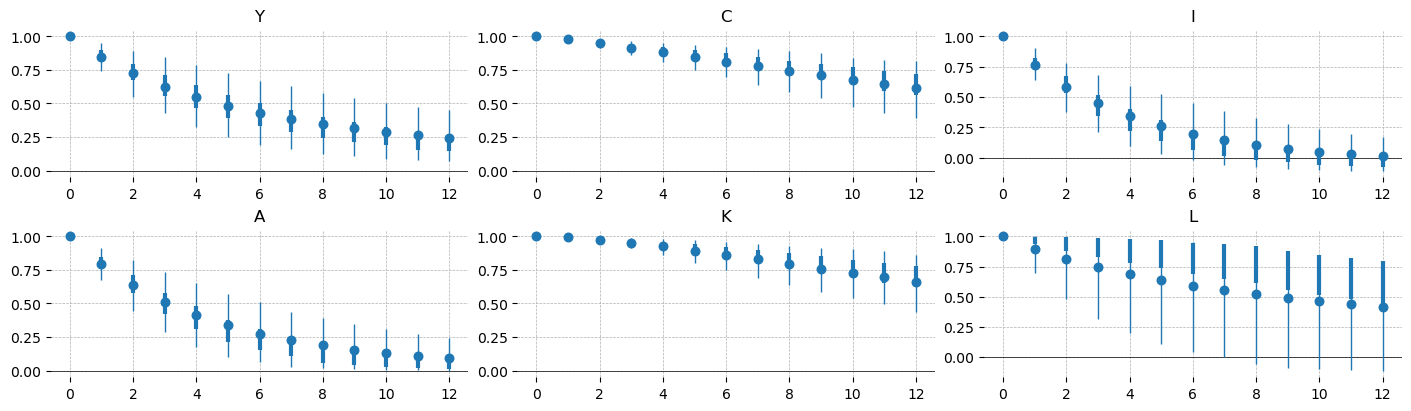

In [28]:
gp.plot_acf(acf, vars_to_plot=["Y", "C", "I", "A", "K", "L"], n_cols=3);

The persistence ordering is the standard one for an RBC. Capital and consumption are the most persistent, capital because it accumulates slowly ($1-\delta \approx 0.97$ per quarter) and consumption because households smooth it; both remain autocorrelated at around 0.6 three years out. Investment is the most transitory, close to white noise by eight quarters. Technology decays geometrically at $\rho_A^k$ (its lag-4 value is $\approx 0.79^4 \approx 0.41$), with output and hours between these cases.

### Model and data: the observed-frequency ACF

The ACF above is the latent quarterly one, useful for reading the model's internal dynamics but not directly comparable to the data, since no quarter is observed. The relevant comparison is at the annual, observed frequency: the autocorrelation of the model's observed series, the four-quarter aggregate sampled once a year with measurement error entering the lag-0 variance, against the empirical ACF of the annual data.

This uses the same method with `observed=True` and `lag_step=4`: annual lag $m$ corresponds to quarterly lag $4m$, the design matrix $Z$ carries the temporal aggregation, and the $H$ term aligns the model's $\rho(0)=1$ with the data. `plot_acf` overlays the data ACF as a reference, which makes this a posterior-predictive check on the autocorrelation of the observed series.

In [29]:
obs_acf = ss_mod.sample_autocorrelation_matrices(idata, n_lags=8, lag_step=4, observed=True)

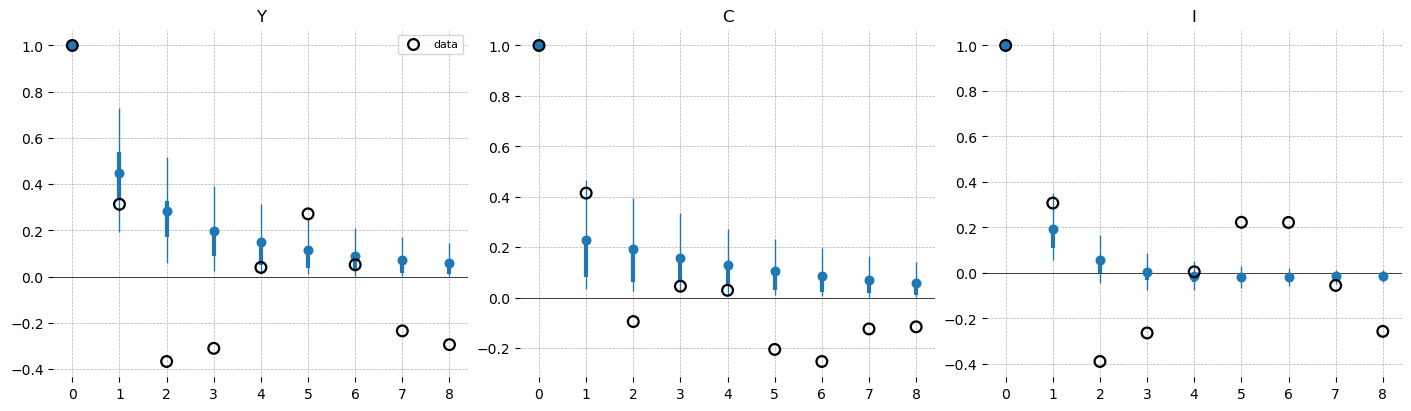

In [30]:
def empirical_acf(x, n_lags):
    x = x[~np.isnan(x)]
    x = x - x.mean()
    denom = (x * x).sum()
    return np.r_[1.0, [(x[k:] * x[:-k]).sum() / denom for k in range(1, n_lags + 1)]]


lags = obs_acf.coords["lag"].values
data_acf = xr.DataArray(
    np.stack([empirical_acf(df_detrended[v].to_numpy(), len(lags) - 1) for v in ss_mod.observed_states], axis=1),
    dims=["lag", "variable"],
    coords={"lag": lags, "variable": list(ss_mod.observed_states)},
)

gp.plot_acf(obs_acf, vars_to_plot=["Y", "C", "I"], reference=data_acf, n_cols=3);

This is the comparison where the model and the data differ most. The model's observed-frequency ACF (blue) inherits the smooth, monotone, positive decay of its single autoregressive driver, remaining positive at every lag. The empirical ACF (black rings) instead turns negative at two-to-four-year lags, with output and investment both around $-0.3$ to $-0.4$, before returning toward zero. A one-shock stationary RBC does not generate this pattern.

Two factors contribute to the difference. The sample is short, roughly fifty annual observations and fewer after the Hamilton warmup, so the empirical ACF is imprecise and its longer lags are difficult to distinguish from zero. The Hamilton filter, which regresses on a two-year-ahead window, also tends to induce negative medium-horizon autocorrelation in the extracted cycle. The model matches the sign and approximate size of the first annual autocorrelation (data $\approx 0.31$, model $\approx 0.45$ for output) but lacks a mechanism for the subsequent mean reversion. Capturing it would require a richer propagation structure, such as habit formation, investment adjustment costs, or an additional shock.

# Authors

- Created by Jesse Grabowski, May 2026

# Watermark

In [31]:
%load_ext watermark
%watermark -n -u -v -iv -m -w

Last updated: Sun, 31 May 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.13.0

Compiler    : Clang 19.1.7 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

arviz                   : 1.1.0
arviz_stats             : 1.1.0
gEconpy                 : 2.1.1.dev11+gdd1b3ddcc.d20260521
matplotlib              : 3.10.9
numpy                   : 2.4.6
pandas                  : 3.0.3
pandas_datareader       : 0.1.dev884+gdf590b00e
preliz                  : 0.25.0
pymc                    : 6.0.0
time_series_transformers: 0.1.dev5+gd474ca52a.d20260531
xarray                  : 2026.4.0

Watermark: 2.6.0

